# Cross-Case-Study Feature Evaluation Summary

**Chapter 8: Feature Engineering**
**Section Reference**: 8.6 - Combining Features and Controlling Search
**Docker image**: `ml4t`

## Purpose

This notebook is the cross-case-study inventory and presentation layer: it
aggregates engineered features and the best registry IC per case study across
all 9 asset classes. It surfaces:
- **Feature counts and families**: how large each case study's feature space is
- **Best IC per case study** (from the model registry): how predictive the
  strongest family is, by asset class
- **Cross-asset patterns**: which feature families generalize vs which are asset-specific

The HAC-adjusted significance and BH-FDR survival counts themselves are computed
upstream, in each case study's `13_model_analysis.py`; this notebook reads and
presents their results rather than recomputing them.

## Learning Objectives

1. Compare feature predictability across diverse asset classes
2. Read off each case study's best registry IC and feature-space size
3. Identify feature families that generalize vs those that are asset-specific
4. Understand how universe size (breadth) interacts with IC magnitude

## Prerequisites

- Case study feature notebooks must have produced `data/features/financial.parquet`
- If feature data is missing for some case studies, they show as "no features"

In [1]:
"""Cross-case-study feature evaluation summary."""

import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import display

warnings.filterwarnings("ignore")

from utils.paths import get_case_study_dir

In [2]:
# Scale parameters (Papermill overrides for testing; readers see production values)
START_DATE = None  # use full dataset

## 1. Load Feature Data

Scan all case study `data/features/` directories for the `financial.parquet`
produced by the feature engineering notebooks. We introspect schemas to count
features and compare across case studies.

In [3]:
CASE_STUDIES = [
    "etfs",
    "crypto_perps_funding",
    "nasdaq100_microstructure",
    "sp500_equity_option_analytics",
    "us_firm_characteristics",
    "fx_pairs",
    "cme_futures",
    "sp500_options",
    "us_equities_panel",
]

DISPLAY_NAMES = {
    "etfs": "ETFs",
    "crypto_perps_funding": "Crypto Perps",
    "nasdaq100_microstructure": "NASDAQ-100",
    "sp500_equity_option_analytics": "S&P 500 Eq+Opt",
    "us_firm_characteristics": "US Firm Chars",
    "fx_pairs": "FX Pairs",
    "cme_futures": "CME Futures",
    "sp500_options": "S&P 500 Options",
    "us_equities_panel": "US Equities",
}

# Columns that are identifiers, not features
_ID_COLS = {"timestamp", "symbol", "product", "stock_id", "instrument_id", "date", "asset"}


def load_feature_info(case_study_id: str) -> dict | None:
    """Load feature summary by introspecting financial.parquet schema."""
    case_dir = get_case_study_dir(case_study_id)
    # Case studies materialize features under <case_dir>/features/ (the
    # naming-conventions doc lists this under data/features/, but the
    # current case-study layout writes directly under features/).
    features_path = case_dir / "features" / "financial.parquet"
    if not features_path.exists():
        return None

    schema = pl.scan_parquet(features_path).collect_schema()
    feature_names = [c for c in schema.names() if c not in _ID_COLS]
    n_features = len(feature_names)

    # Group features into families by prefix (e.g. "mom_", "vol_", "carry_")
    family_counts: dict[str, int] = {}
    for name in feature_names:
        parts = name.split("_")
        family = parts[0] if len(parts) > 1 else "other"
        family_counts[family] = family_counts.get(family, 0) + 1

    return {
        "n_features": n_features,
        "feature_names": feature_names,
        "family_counts": family_counts,
    }

In [4]:
# Load all feature info
all_results: dict[str, dict] = {}
evaluated: dict[str, dict] = {}
awaiting: list[str] = []

for cs in CASE_STUDIES:
    result = load_feature_info(cs)
    if result is None:
        awaiting.append(cs)
        continue
    all_results[cs] = result
    evaluated[cs] = result

print(f"Case studies with features: {len(evaluated)}/{len(CASE_STUDIES)}")
if evaluated:
    print(f"  Available: {', '.join(DISPLAY_NAMES[cs] for cs in evaluated)}")
if awaiting:
    print(f"  No features: {', '.join(DISPLAY_NAMES.get(cs, cs) for cs in awaiting)}")

Case studies with features: 9/9
  Available: ETFs, Crypto Perps, NASDAQ-100, S&P 500 Eq+Opt, US Firm Chars, FX Pairs, CME Futures, S&P 500 Options, US Equities


## 2. Feature Count Comparison

How many features and feature families does each case study engineer? (The
multiple-testing survival counts are produced upstream in each case study's
`13_model_analysis.py`; here we inventory the feature space.)

In [5]:
if evaluated:
    summary_rows = []
    for cs, result in evaluated.items():
        summary_rows.append(
            {
                "case_study": DISPLAY_NAMES[cs],
                "n_features": result["n_features"],
                "n_families": len(result["family_counts"]),
                "top_families": ", ".join(
                    f"{k}({v})"
                    for k, v in sorted(result["family_counts"].items(), key=lambda x: -x[1])[:5]
                ),
            }
        )

    summary_df = pl.DataFrame(summary_rows)
    display(summary_df)
else:
    print("No feature data available yet. Run case study feature notebooks first.")

case_study,n_features,n_families,top_families
str,i64,i64,str
"""ETFs""",57,24,"""ret(9), vol(9), sharpe(9), mom…"
"""Crypto Perps""",39,7,"""premium(28), funding(4), price…"
"""NASDAQ-100""",66,18,"""rel(8), signed(8), rv(8), micr…"
"""S&P 500 Eq+Opt""",45,13,"""iv(12), mom(9), term(5), skew(…"
"""US Firm Chars""",57,9,"""other(39), composite(7), inter…"
"""FX Pairs""",51,15,"""rank(9), vol(8), ret(7), usd(5…"
"""CME Futures""",63,21,"""carry(11), sharpe(8), mom(7), …"
"""S&P 500 Options""",51,14,"""instr(13), iv(10), vrp(9), rv(…"
"""US Equities""",63,23,"""mom(10), past(9), sharpe(9), v…"


## 3. Feature Count Comparison

How does feature set size vary across case studies? More features provide
a richer signal space but also increase the multiple testing burden.

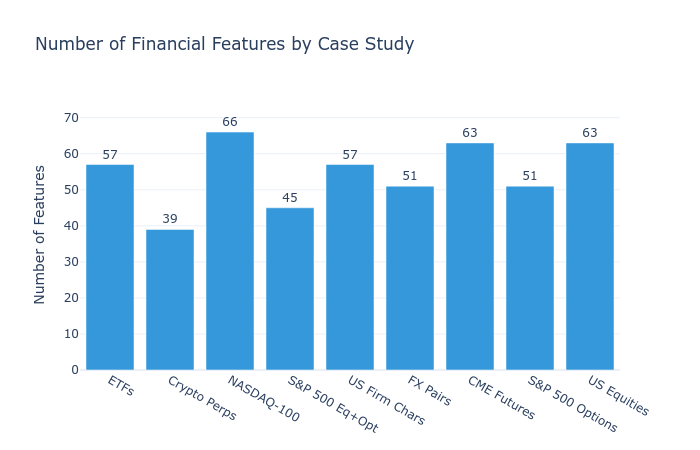

In [6]:
if evaluated:
    cs_names = [DISPLAY_NAMES[cs] for cs in evaluated]
    n_features = [evaluated[cs]["n_features"] for cs in evaluated]

    fig = go.Figure()
    fig.add_trace(
        go.Bar(
            x=cs_names,
            y=n_features,
            marker_color="#3498db",
            text=[str(n) for n in n_features],
            textposition="outside",
        )
    )
    fig.update_layout(
        title="Number of Financial Features by Case Study",
        yaxis_title="Number of Features",
        template="plotly_white",
        height=450,
    )
    fig.show()
else:
    print("No feature data available.")

## 4. Feature Family Distribution

Which feature families are used across asset classes? This heatmap shows
the number of features per family per case study, revealing cross-asset
patterns (e.g., momentum features everywhere) vs asset-specific features
(e.g., carry only in futures/FX).

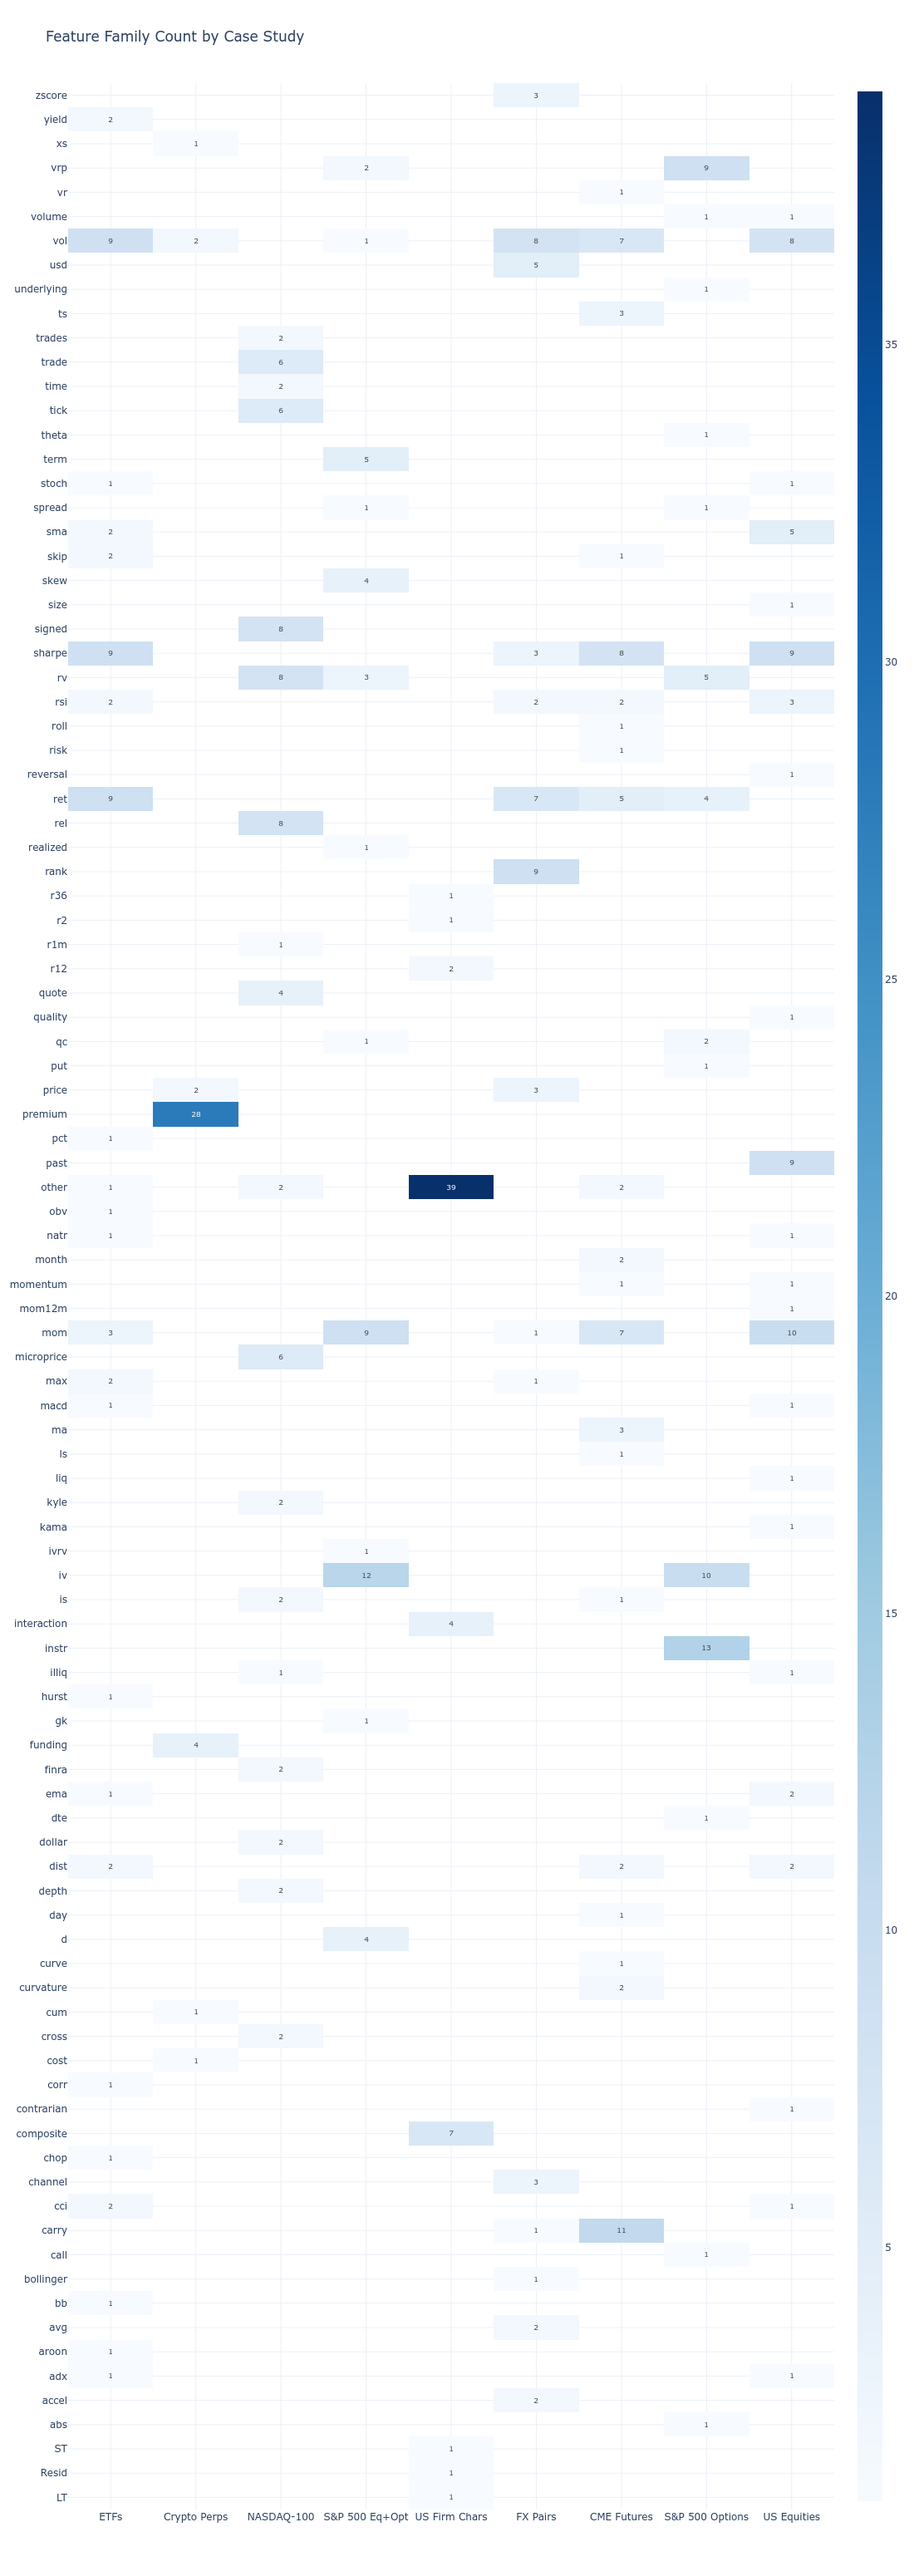

In [7]:
if evaluated:
    # Collect all family names across case studies
    all_families: set[str] = set()
    for cs in evaluated:
        all_families.update(evaluated[cs]["family_counts"].keys())

    all_families_sorted = sorted(all_families)

    if all_families_sorted:
        heatmap_data = []
        for family in all_families_sorted:
            row = []
            for cs in evaluated:
                count = evaluated[cs]["family_counts"].get(family, 0)
                row.append(count if count > 0 else float("nan"))
            heatmap_data.append(row)

        fig = go.Figure(
            data=go.Heatmap(
                z=heatmap_data,
                x=[DISPLAY_NAMES[cs] for cs in evaluated],
                y=all_families_sorted,
                colorscale="Blues",
                text=[
                    [f"{int(v)}" if not np.isnan(v) else "" for v in row] for row in heatmap_data
                ],
                texttemplate="%{text}",
                textfont={"size": 9},
            )
        )
        fig.update_layout(
            title="Feature Family Count by Case Study",
            template="plotly_white",
            height=max(400, len(all_families_sorted) * 30 + 100),
            width=max(600, len(evaluated) * 100 + 200),
        )
        fig.show()
    else:
        print("No family-level data available.")
else:
    print("No feature data available.")

## 5. Representative Features Across Case Studies

A sample of each case study's feature space — the first few feature names in
schema order — to illustrate the engineered inputs. This is an inventory view,
not an IC ranking (per-feature IC is computed in each case study's evaluation
notebook).

In [8]:
if evaluated:
    top_features_all = []
    for cs in evaluated:
        # Show first 5 feature names per case study
        for feat_name in evaluated[cs]["feature_names"][:5]:
            top_features_all.append(
                {
                    "case_study": DISPLAY_NAMES[cs],
                    "feature": feat_name,
                }
            )

    if top_features_all:
        top_df = pl.DataFrame(top_features_all)
        display(top_df)
else:
    print("No feature data available.")

case_study,feature
str,str
"""ETFs""","""ret_5d"""
"""ETFs""","""ret_10d"""
"""ETFs""","""ret_21d"""
"""ETFs""","""ret_42d"""
"""ETFs""","""ret_63d"""
…,…
"""US Equities""","""past_ret_5d"""
"""US Equities""","""past_ret_10d"""
"""US Equities""","""past_ret_21d"""


## 6. Correlation Structure Summary

Feature redundancy across case studies. How many feature pairs
have correlation above 0.7? High redundancy wastes model capacity.

In [9]:
if evaluated:
    corr_data = []
    for cs in evaluated:
        corr_data.append(
            {
                "case_study": DISPLAY_NAMES[cs],
                "n_features": evaluated[cs]["n_features"],
                "n_families": len(evaluated[cs]["family_counts"]),
            }
        )

    corr_df = pl.DataFrame(corr_data)
    display(corr_df)
    print("\nNote: For full correlation analysis, run the per-case-study evaluation notebooks.")
else:
    print("No feature data available.")

case_study,n_features,n_families
str,i64,i64
"""ETFs""",57,24
"""Crypto Perps""",39,7
"""NASDAQ-100""",66,18
"""S&P 500 Eq+Opt""",45,13
"""US Firm Chars""",57,9
"""FX Pairs""",51,15
"""CME Futures""",63,21
"""S&P 500 Options""",51,14
"""US Equities""",63,23



Note: For full correlation analysis, run the per-case-study evaluation notebooks.


## 7. Breadth vs IC: The Fundamental Law Perspective

The Fundamental Law of Active Management says:

$$IR \approx IC \times \sqrt{BR}$$

where $BR$ is the number of independent bets (roughly the universe size).
A case study with IC = 0.01 and 3,000 stocks achieves IR = 0.55,
while IC = 0.03 with 20 pairs gives IR = 0.13. Breadth matters enormously.

In [10]:
from case_studies.utils.analytics import DATASET_META, load_best_ic_per_family

if evaluated:
    # Load best IC per family from registry to combine with universe metadata
    best_ic_df = load_best_ic_per_family()

    if not best_ic_df.is_empty():
        # Get best IC per case study (across all families)
        best_per_cs = (
            best_ic_df.sort("ic_mean", descending=True, nulls_last=True)
            .group_by("case_study")
            .first()
            .select("case_study", "ic_mean")
        )

        breadth_data = []
        for row in best_per_cs.iter_rows(named=True):
            cs = row["case_study"]
            meta = DATASET_META.get(cs, {})
            n_entities = meta.get("entities", 0)
            ic = abs(row["ic_mean"]) if row["ic_mean"] is not None else 0.0
            if n_entities == 0 or ic == 0.0:
                continue
            ir_estimate = ic * np.sqrt(n_entities)
            breadth_data.append(
                {
                    "case_study": DISPLAY_NAMES.get(cs, cs),
                    "universe_size": n_entities,
                    "best_abs_ic": round(ic, 4),
                    "estimated_ir": round(ir_estimate, 2),
                }
            )

        if breadth_data:
            breadth_df = pl.DataFrame(breadth_data).sort("estimated_ir", descending=True)
            display(breadth_df)
        else:
            print("No IC data available from registry.")
    else:
        print("No model IC data in registry yet.")
else:
    print("No feature data available.")

case_study,universe_size,best_abs_ic,estimated_ir
str,i64,f64,f64
"""US Firm Chars""",2483,0.0803,4.0
"""US Equities""",3199,0.0318,1.8
"""ETFs""",99,0.0917,0.91
"""S&P 500 Options""",612,0.0182,0.45
"""S&P 500 Eq+Opt""",638,0.0114,0.29
"""CME Futures""",30,0.042,0.23
"""Crypto Perps""",21,0.0293,0.13
"""NASDAQ-100""",114,0.006,0.06
"""FX Pairs""",20,0.0106,0.05


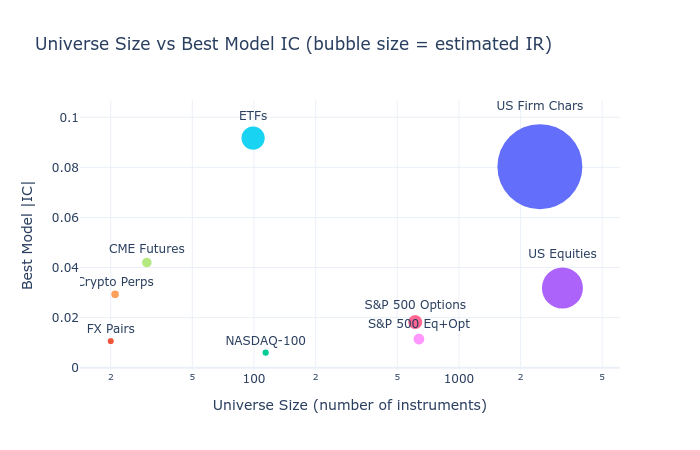

In [11]:
# Visualize breadth vs IC
if evaluated and "breadth_data" in dir() and breadth_data:
    fig = go.Figure()
    for brow in breadth_data:
        fig.add_trace(
            go.Scatter(
                x=[brow["universe_size"]],
                y=[brow["best_abs_ic"]],
                mode="markers+text",
                text=[brow["case_study"]],
                textposition="top center",
                marker=dict(size=brow["estimated_ir"] * 20 + 5),
                showlegend=False,
            )
        )

    fig.update_layout(
        title="Universe Size vs Best Model IC (bubble size = estimated IR)",
        xaxis_title="Universe Size (number of instruments)",
        yaxis_title="Best Model |IC|",
        xaxis_type="log",
        template="plotly_white",
        height=450,
    )
    fig.show()

## What the Panels Above Show

The notebook aggregates whatever is present in each case study's
`data/features/financial.parquet` and the model registry. The substantive
findings — which feature families have predictive content for which label
and horizon, how many features survive HAC + BH-FDR, and how breadth
interacts with IC magnitude — are produced by the per-case-study evaluation
notebooks (`13_model_analysis.py` in each case study). This summary
notebook is a cross-case-study inventory and presentation layer; it does
not itself compute IC or run multiple-testing correction.

**Next**: See `09_model_based_features/case_study_temporal_summary` for the
temporal/model-based feature companion view.
**Book**: Chapter 8.6 discusses combining features and controlling the
search space to avoid data mining.